In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1- DataSet

In [8]:
# Generates a custom dataset with a continuous target variable
x, y = make_regression(n_samples= 100, n_features= 1, noise= 10)
y = y + abs(y/2) # Random non-linear equation

(100, 1) (100,)
(100, 1) (100, 1)


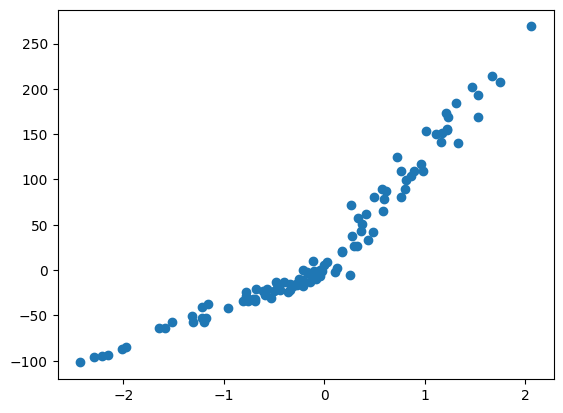

In [9]:
plt.scatter(x,y)
print(x.shape , y.shape)
# Fix the shape of y: make_regression outputs a flat array (n,). 
# We must reshape it into a proper matrix column (n, 1) so our math formulas execute correctly.
y =y.reshape(y.shape[0], 1)
print(x.shape , y.shape)

# 2- X Matrix and Theta Vector Set Up

f(x) = aX^2 + bX + c ==> *F = X . Theta*

In [11]:
# X matrix:
once_matrix = np.ones(x.shape)
X = np.hstack((x,once_matrix))
X = np.hstack((x**2,X))
print(X.shape)
print(X)
# Theta Vector:
Theta = np.random.randn(3,1)
print( "theta value is\n", Theta, "\nand it's shape is: ", Theta.shape)

(100, 3)
[[ 5.84524543e-01  7.64542048e-01  1.00000000e+00]
 [ 3.29229496e-01 -5.73785235e-01  1.00000000e+00]
 [ 4.64392402e-01 -6.81463427e-01  1.00000000e+00]
 [ 2.33846517e+00  1.52920410e+00  1.00000000e+00]
 [ 1.49241602e+00 -1.22164480e+00  1.00000000e+00]
 [ 1.14982445e-01 -3.39090615e-01  1.00000000e+00]
 [ 7.40723210e-01  8.60652781e-01  1.00000000e+00]
 [ 1.75951540e+00  1.32646726e+00  1.00000000e+00]
 [ 3.54882274e-01 -5.95719963e-01  1.00000000e+00]
 [ 8.04802869e-01  8.97108059e-01  1.00000000e+00]
 [ 2.36392819e-01  4.86202446e-01  1.00000000e+00]
 [ 2.16796104e+00  1.47239975e+00  1.00000000e+00]
 [ 1.36356267e+00  1.16771686e+00  1.00000000e+00]
 [ 4.49407160e-02 -2.11992255e-01  1.00000000e+00]
 [ 2.18391299e-01 -4.67323548e-01  1.00000000e+00]
 [ 5.90294889e+00 -2.42959850e+00  1.00000000e+00]
 [ 1.47902503e+00  1.21615173e+00  1.00000000e+00]
 [ 9.64397728e-02 -3.10547537e-01  1.00000000e+00]
 [ 2.84763066e-01 -5.33631957e-01  1.00000000e+00]
 [ 1.65930391e-05 -4.0

# 3-Model

In [12]:
def model(X, Theta):
    return X.dot(Theta)

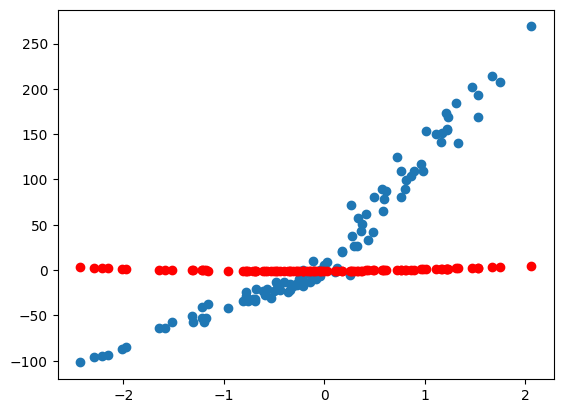

In [27]:
plt.scatter(x,y)
plt.scatter(x, model(X,Theta), c='r')

# 4-Cost Function
**==>Means Squared Error**



![Alt text](images/MSE.png)

In [14]:
def cost_function(X, Theta, y):
    m = len(y)
    return 1/(2*m) * np.sum((model(X,Theta)-y)**2)

In [15]:
cost_function(X,Theta,y)

np.float64(3796.283714067709)

# 5-Optimization Algorithm

**==>Gradient Descent**


**1-Gradient**


![Alt text](images/Gradient.png)

In [16]:
def Gradient(X,y,Theta):
    m= len(y)
    return (1/m)* X.T.dot(model(X,Theta)-y) 

**2-Gradient Descent**


![Alt text](images/Grad_Des.png)

In [17]:
def Gradient_Descent(X, y, Theta, learning_rate, iterations):
    cost_history = np.zeros(iterations)
    for i in range(0,iterations):
        Theta = Theta - learning_rate * Gradient(X,y,Theta)
        cost_history[i] = cost_function(X,Theta,y)
    return Theta , cost_history

# 6-Model training

In [21]:
theta_final, cost_history= Gradient_Descent(X=X, y=y, Theta=Theta, learning_rate= 0.001, iterations= 10000)

[[19.19482951]
 [86.77395331]
 [15.12831908]]


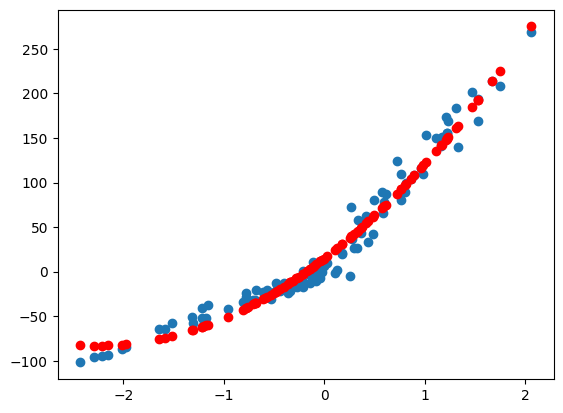

In [23]:
print(theta_final)
prediction= model(X=X, Theta= theta_final)
plt.scatter(x,y)
plt.scatter(x,prediction, c='r')

# 7-Learning Curve

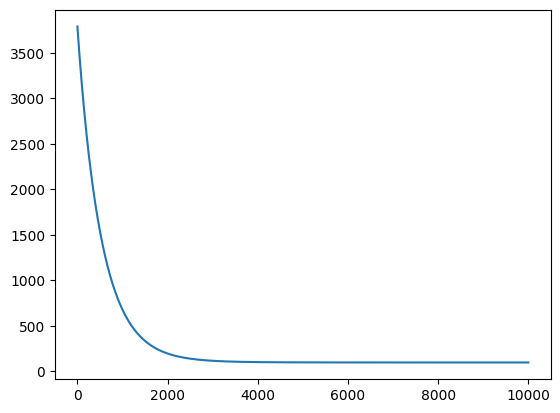

In [24]:
plt.plot(range(10000), cost_history)

# 8-The Coefficient of Determination

**It indicates how well a model fits data, with 1 being a perfect fit and 0 showing no explanatory power**

![Alt text](images/Det_Coef.png)

In [25]:
def coef_det(y, prediction):
    u= ((y - prediction)**2).sum()
    v= ((y - y.mean())**2).sum()
    return 1- u/v

In [26]:
Score = coef_det(y, prediction)
print(f"R-Squared Score: {Score:.4f}")
print(f"Mean Squared Error: {cost_function(X,theta_final,y)}")

R-Squared Score: 0.9712
Mean Squared Error: 98.57977201601636
